In [75]:
import kaggle
import os
import random
from tqdm import tqdm
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as ipd
import datasets
import torch
import torchaudio
from pathlib import Path

Setting seeds and torch config for reproducibility.

In [76]:
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed()

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DEVICE = "cpu"
print('Device:', DEVICE)

Device: cpu


In [77]:
#!kaggle datasets download -d mfekadu/darpa-timit-acousticphonetic-continuous-speech -p timit --unzip

In [78]:
timit_path = "./timit/"
df_train = pd.read_csv(os.path.join(timit_path, 'train_data.csv'))
df_test = pd.read_csv(os.path.join(timit_path, 'test_data.csv'))
df = pd.concat([df_train, df_test])
df = df[df['is_converted_audio'] == False]
df_train = df[df['test_or_train'] == "TRAIN"]
df_test  = df[df['test_or_train'] == "TEST"]

In [79]:
df_train.head()

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False
5,6.0,TRAIN,DR4,MMDM0,SI681.TXT,TRAIN/DR4/MMDM0/SI681.TXT,TRAIN\\DR4\\MMDM0\\SI681.TXT,False,False,False,False,True


In [80]:
df_test.head()

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TEST,DR4,MGMM0,SX139.WAV,TEST/DR4/MGMM0/SX139.WAV,TEST\\DR4\\MGMM0\\SX139.WAV,False,True,False,False,False
2,3.0,TEST,DR4,MGMM0,SX139.TXT,TEST/DR4/MGMM0/SX139.TXT,TEST\\DR4\\MGMM0\\SX139.TXT,False,False,False,False,True
3,4.0,TEST,DR4,MGMM0,SI499.WRD,TEST/DR4/MGMM0/SI499.WRD,TEST\\DR4\\MGMM0\\SI499.WRD,False,False,True,False,False
4,5.0,TEST,DR4,MGMM0,SX319.WRD,TEST/DR4/MGMM0/SX319.WRD,TEST\\DR4\\MGMM0\\SX319.WRD,False,False,True,False,False
5,6.0,TEST,DR4,MGMM0,SX319.PHN,TEST/DR4/MGMM0/SX319.PHN,TEST\\DR4\\MGMM0\\SX319.PHN,False,False,False,True,False


In [81]:
df.head()

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False
5,6.0,TRAIN,DR4,MMDM0,SI681.TXT,TRAIN/DR4/MMDM0/SI681.TXT,TRAIN\\DR4\\MMDM0\\SI681.TXT,False,False,False,False,True


In [82]:
PHONEME_61_TO_39 = {
    "iy": "iy",
    "ih": "ih",
    "eh": "eh",
    "ae": "ae",
    "ix": "ih",
    "ax": "ah",
    "ax-h": "ah",
    "ah": "ah",
    "uw": "uw",
    "ux": "uw",
    "uh": "uh",
    "ao": "aa",
    "aa": "aa",
    "ey": "ey",
    "ay": "ay",
    "oy": "oy",
    "aw": "aw",
    "ow": "ow",
    "er": "er",
    "axr": "er",
    "l": "l",
    "el": "l",
    "r": "r",
    "y": "y",
    "w": "w",
    "m": "m",
    "em": "m",
    "n": "n",
    "en": "n",
    "nx": "n",
    "ng": "ng",
    "eng": "ng",
    "ch": "ch",
    "jh": "jh",
    "dh": "dh",
    "z": "z",
    "zh": "sh",
    "v": "v",
    "f": "f",
    "th": "th",
    "s": "s",
    "sh": "sh",
    "hh": "hh",
    "hv": "hh",
    "b": "b",
    "d": "d",
    "dx": "dx",
    "g": "g",
    "p": "p",
    "t": "t",
    "k": "k",
    "pcl": "h#",
    "tcl": "h#",
    "kcl": "h#",
    "bcl": "h#",
    "dcl": "h#",
    "gcl": "h#",
    "qcl": "h#",
    "h#": "h#",
    "#h": "h#",
    "pau": "h#",
    "epi": "h#",
    "q": "h#",
}

TIMIT provides phoneme annotations in a 61-phoneme inventory, but the standard evaluation protocol uses a reduced 39-phoneme set.

This mapping merges similar phonemes and collapses silence-related symbols into a shared class.  
Using this reduced inventory makes the results comparable to the standard phoneme recognition setup.

In [83]:
def map_phoneme_61_to_39(ph, mapping=PHONEME_61_TO_39):
    ph = ph.strip()
    if ph not in mapping:
        raise ValueError(f"Unknown TIMIT phoneme: '{ph}'")
    return mapping[ph]

In [84]:
def map_phoneme_sequence_61_to_39(
    phonemes,
    mapping=PHONEME_61_TO_39
):
    return [map_phoneme_61_to_39(ph, mapping) for ph in phonemes]

In [85]:
def read_timit_txt_file(txt_path):
    txt_path = Path(txt_path)

    with txt_path.open("r", encoding="utf-8") as f:
        line = f.readline().strip()

    parts = line.split(maxsplit=2)
    if len(parts) < 3:
        raise ValueError(f"Invalid .TXT line in {txt_path}: {line!r}")

    return parts[2]

In [86]:
def read_timit_phn_file(phn_path):
    phonemes = []

    with open(phn_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            phonemes.append(parts[-1])

    return phonemes

Here we combine all files belonging to the same utterance into a single structured record.

Each record contains:
- utterance ID
- speaker ID
- split information
- path to the waveform
- mapped phoneme sequence
- text transcription

This makes the dataset easier to process and train on.

In [87]:
def build_timit_utterance_record(
    wav_path,
    drop_silence=False,
):
    wav_path = Path(wav_path)

    if not wav_path.exists():
        raise FileNotFoundError(f"WAV file not found: {wav_path}")

    stem = wav_path.stem
    phn_path = wav_path.with_suffix(".PHN")
    txt_path = wav_path.with_suffix(".TXT")

    if not phn_path.exists():
        raise FileNotFoundError(f"PHN file not found for {wav_path}")
    if not txt_path.exists():
        raise FileNotFoundError(f"TXT file not found for {wav_path}")

    # .../TRAIN/DR1/FCJF0/SA1.WAV
    speaker_id = wav_path.parent.name
    dialect_region = wav_path.parent.parent.name
    split = wav_path.parent.parent.parent.name.upper()

    phonemes_61 = read_timit_phn_file(phn_path)

    phonemes_39 = map_phoneme_sequence_61_to_39(phonemes_61)

    phoneme_text_39 = " ".join(phonemes_39)

    text = read_timit_txt_file(txt_path)

    utt_id = f"{split}_{dialect_region}_{speaker_id}_{stem}"

    return {
        "utt_id": utt_id,
        "speaker_id": speaker_id,
        "dialect_region": dialect_region,
        "split": split,
        "wav_path": str(wav_path),
        "phonemes_39": phonemes_39,
        "phoneme_text_39": phoneme_text_39,
        "text": text,
    }

In [88]:
def build_timit_manifest(timit_root):

    wav_files = sorted(Path(timit_root).rglob("*.WAV"))

    records = []

    for wav_path in tqdm(wav_files):

        record = build_timit_utterance_record(wav_path)

        records.append(record)

    df = pd.DataFrame(records)

    return df

In [89]:
manifest_df = build_timit_manifest(timit_path)
manifest_df.head()

100%|██████████| 6300/6300 [00:01<00:00, 5794.95it/s]


,utt_id,speaker_id,dialect_region,split,wav_path,phonemes_39,phoneme_text_39,text
0,TEST_DR1_FAKS0_SA1,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SA1.WAV,"[h#, sh, iy, hh, ae, h#, d, y, er, h#, d, aa, ...",h# sh iy hh ae h# d y er h# d aa r h# k s uw d...,She had your dark suit in greasy wash water al...
1,TEST_DR1_FAKS0_SA2,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SA2.WAV,"[h#, d, ow, n, ae, s, h#, m, iy, h#, t, ih, h#...",h# d ow n ae s h# m iy h# t ih h# k eh r iy ih...,Don't ask me to carry an oily rag like that.
2,TEST_DR1_FAKS0_SI1573,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SI1573.WAV,"[h#, hh, ih, z, h#, k, ae, h#, t, ih, n, w, ah...",h# hh ih z h# k ae h# t ih n w ah s th ih n ae...,His captain was thin and haggard and his beaut...
3,TEST_DR1_FAKS0_SI2203,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SI2203.WAV,"[h#, dh, ih, r, iy, z, ah, n, z, f, er, dh, ih...",h# dh ih r iy z ah n z f er dh ih s h# d ay v ...,The reasons for this dive seemed foolish now.
4,TEST_DR1_FAKS0_SI943,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SI943.WAV,"[h#, p, er, h#, d, ah, h#, k, sh, ih, n, m, ey...",h# p er h# d ah h# k sh ih n m ey f aa l f aa ...,Production may fall far below expectations.


In [90]:
train_df = manifest_df[manifest_df["split"] == "TRAIN"]
test_df = manifest_df[manifest_df["split"] == "TEST"]

In [91]:
all_phonemes = set()

for seq in manifest_df["phonemes_39"]:
    all_phonemes.update(seq)

phoneme_list = sorted(list(all_phonemes))

In [92]:
phoneme2id = {p:i for i,p in enumerate(phoneme_list)}

id2phoneme = {i:p for p,i in phoneme2id.items()}


blank_id = len(phoneme2id)
num_classes = blank_id + 1

In [93]:
def load_audio(path):

    waveform, sr = torchaudio.load(path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    return waveform.squeeze(0)

We use a pretrained self-supervised speech model as a feature extractor. 

In [94]:
from transformers import Wav2Vec2Model
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

ssl_model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

ssl_model.eval()

/Users/akravchuk/vscodeprojects/sound_processing/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

In [95]:
def split_dataframe(df, val_ratio=0.1, seed=SEED):
    n = len(df)

    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)

    val_size = int(n * val_ratio)

    val_idx = perm[:val_size]
    train_idx = perm[val_size:]

    train_df = df.iloc[train_idx.numpy()].reset_index(drop=True)
    val_df = df.iloc[val_idx.numpy()].reset_index(drop=True)

    return train_df, val_df

TIMIT already has an official split between train and test, but we split the train manually into train and validation data. Test is untouched until evaluation.

In [96]:
train_df, val_df = split_dataframe(train_df, val_ratio=0.1)

print(len(train_df))
print(len(val_df))
print(len(test_df))

4158
462
1680


Helper functions to decode and encode phonemes from dicts.

In [97]:
def encode_phonemes(phonemes, phoneme2id):
    return [phoneme2id[p] for p in phonemes]

def decode_phonemes(ids, id2phoneme):
    return [id2phoneme[i] for i in ids]

In [98]:
sample_ids = encode_phonemes(train_df.iloc[0]["phonemes_39"], phoneme2id)
print(sample_ids)
print(decode_phonemes(sample_ids, id2phoneme))

[15, 8, 12, 0, 13, 15, 31, 23, 15, 14, 25, 3, 15, 23, 18, 18, 35, 23, 18, 23, 15]
['h#', 'dh', 'ey', 'aa', 'f', 'h#', 't', 'n', 'h#', 'g', 'ow', 'aw', 'h#', 'n', 'iy', 'iy', 'v', 'n', 'iy', 'n', 'h#']


In [99]:
ssl_model = ssl_model.to(DEVICE)
ssl_model.eval()

sample_row = train_df.iloc[0]
audio = load_audio(sample_row["wav_path"])

inputs = processor(
    audio,
    sampling_rate=16000,
    return_tensors="pt"
)
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

with torch.no_grad():
    outputs = ssl_model(**inputs, output_hidden_states=True)

hidden_states = outputs.hidden_states
print("hidden layers:", len(hidden_states))
for i, h in enumerate(hidden_states):
    print(f"  layer {i:2d}: {h.shape}")

features = hidden_states[-1].squeeze(0).cpu()
print("features shape:", features.shape)
print(sample_row["phonemes_39"])

hidden layers: 13
  layer  0: torch.Size([1, 89, 768])
  layer  1: torch.Size([1, 89, 768])
  layer  2: torch.Size([1, 89, 768])
  layer  3: torch.Size([1, 89, 768])
  layer  4: torch.Size([1, 89, 768])
  layer  5: torch.Size([1, 89, 768])
  layer  6: torch.Size([1, 89, 768])
  layer  7: torch.Size([1, 89, 768])
  layer  8: torch.Size([1, 89, 768])
  layer  9: torch.Size([1, 89, 768])
  layer 10: torch.Size([1, 89, 768])
  layer 11: torch.Size([1, 89, 768])
  layer 12: torch.Size([1, 89, 768])
features shape: torch.Size([89, 768])
['h#', 'dh', 'ey', 'aa', 'f', 'h#', 't', 'n', 'h#', 'g', 'ow', 'aw', 'h#', 'n', 'iy', 'iy', 'v', 'n', 'iy', 'n', 'h#']


The pretrained model outputs hidden states for multiple transformer layers.  
Instead of using only the last layer, we can also extract intermediate layers and compare their usefulness for phoneme recognition.

This is important because different layers may encode different levels of phonetic information.

In [100]:
def extract_ssl_features(audio, processor, ssl_model, device, layer_index=-1):
    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = ssl_model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states
    features = hidden_states[layer_index].squeeze(0).cpu()
    return features

Running the SSL encoder for every utterance during every training epoch would be very slow.  
To make experiments efficient, we extract the hidden representations once and save them as cached tensors.

In [101]:

def build_cached_dataset(df, processor, ssl_model, device, phoneme2id, layer_index=-1):
    items = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        audio = load_audio(row["wav_path"])

        features = extract_ssl_features(
            audio=audio,
            processor=processor,
            ssl_model=ssl_model,
            device=device,
            layer_index=layer_index,
        )

        label_ids = encode_phonemes(row["phonemes_39"], phoneme2id)

        items.append({
            "utt_id": row["utt_id"],
            "features": features,  # [T, 768]
            "labels": torch.tensor(label_ids, dtype=torch.long),
            "phonemes_39": row["phonemes_39"],
            "text": row["text"],
        })

    return items

Each dataset item contains:
- frame-level SSL features
- the target phoneme sequence as integer labels
- metadata such as utterance ID and transcription

In [102]:
from torch.utils.data import Dataset

class PhonemeDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]

In [103]:
if os.path.exists("train_items_layer_last.pt"):
    train_items = torch.load("train_items_layer_last.pt")
    print("Downloaded train_items from cache")
else:
    train_items = build_cached_dataset(
        train_df, processor, ssl_model, DEVICE, phoneme2id, layer_index=-1
    )
    torch.save(train_items, "train_items_layer_last.pt")
    print("Built and saved train_items")

if os.path.exists("val_items_layer_last.pt"):
    val_items = torch.load("val_items_layer_last.pt")
    print("Downloaded val_items from cache")
else:
    val_items = build_cached_dataset(
        val_df, processor, ssl_model, DEVICE, phoneme2id, layer_index=-1
    )
    torch.save(val_items, "val_items_layer_last.pt")
    print("Built and saved val_items")

if os.path.exists("test_items_layer_last.pt"):
    test_items = torch.load("test_items_layer_last.pt")
    print("Downloaded test_items from cache")
else:
    test_items = build_cached_dataset(
        test_df, processor, ssl_model, DEVICE, phoneme2id, layer_index=-1
    )
    torch.save(test_items, "test_items_layer_last.pt")
    print("Built and saved test_items")

train_dataset = PhonemeDataset(train_items)
val_dataset = PhonemeDataset(val_items)
test_dataset = PhonemeDataset(test_items)

Downloaded train_items from cache
Downloaded val_items from cache
Downloaded test_items from cache


Different utterances have different durations, so both the input feature sequences and target phoneme sequences have variable lengths.

The custom collate function:
- pads feature sequences within the batch
- concatenates target labels
- stores input and target lengths

This is required for training with CTC loss.

In [104]:
from torch.nn.utils.rnn import pad_sequence

def phoneme_collate_fn(batch):
    feature_list = [item["features"] for item in batch]
    label_list = [item["labels"] for item in batch]

    input_lengths = torch.tensor(
        [x.shape[0] for x in feature_list],
        dtype=torch.long
    )

    target_lengths = torch.tensor(
        [y.shape[0] for y in label_list],
        dtype=torch.long
    )

    padded_features = pad_sequence(feature_list, batch_first=True)
    flat_labels = torch.cat(label_list)

    return {
        "features": padded_features,
        "labels": flat_labels,
        "input_lengths": input_lengths,
        "target_lengths": target_lengths,
        "raw_labels": label_list,
        "utt_ids": [item["utt_id"] for item in batch],
        "phonemes_39": [item["phonemes_39"] for item in batch],
    }

In [105]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=phoneme_collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=phoneme_collate_fn,
)

batch = next(iter(train_loader))

print(batch["features"].shape)
print(batch["labels"].shape)
print(batch["input_lengths"])
print(batch["target_lengths"])

torch.Size([4, 206, 768])
torch.Size([165])
tensor([166, 102, 165, 206])
tensor([38, 24, 42, 61])


In [106]:
import torch.nn as nn

class LinearHead(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

class BiLSTMHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)
        return self.classifier(out)

class MLPHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.mlp(x)


In [107]:
def build_head(head_name, input_dim, num_classes):
    if head_name == "linear":
        return LinearHead(input_dim=input_dim, num_classes=num_classes)
    elif head_name == "bilstm":
        return BiLSTMHead(
            input_dim=input_dim,
            hidden_dim=256,
            num_layers=2,
            num_classes=num_classes,
            dropout=0.1,
        )
    elif head_name == "mlp":
        return MLPHead(
            input_dim=input_dim,
            hidden_dim=256,
            num_classes=num_classes,
            dropout=0.1,
        )
    else:
        raise ValueError(f"Unknown head: {head_name}")

The model outputs frame-level phoneme logits.  
To convert them into a phoneme sequence, we apply greedy CTC decoding:
- choose the most likely class at each frame
- remove repeated predictions
- remove blank symbols

This produces the final predicted phoneme sequence.

In [108]:
def greedy_ctc_decode(logits, blank_id):
    pred_ids = logits.argmax(dim=-1)
    results = []

    for seq in pred_ids:
        collapsed = []
        prev = None

        for idx in seq.tolist():
            if idx != prev and idx != blank_id:
                collapsed.append(idx)
            prev = idx

        results.append(collapsed)

    return results

PER is the standard metric for phoneme recognition.  
It is computed as the edit distance between the reference and predicted phoneme sequences, normalized by the length of the reference sequence.

Lower PER indicates better phoneme recognition performance.

In [109]:
def phoneme_distance(ref, hyp):
    n = len(ref)
    m = len(hyp)

    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]


def phoneme_error_rate(reference, hypothesis):
    if len(reference) == 0:
        return 0.0 if len(hypothesis) == 0 else 1.0
    return phoneme_distance(reference, hypothesis) / len(reference)

In [110]:
def train_one_epoch(model, loader, optimizer, ctc_loss, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        features = batch["features"].to(device)
        labels = batch["labels"].to(device)
        input_lengths = batch["input_lengths"].to(device)
        target_lengths = batch["target_lengths"].to(device)

        optimizer.zero_grad()

        logits = model(features)
        log_probs = logits.log_softmax(dim=-1).transpose(0, 1)

        loss = ctc_loss(
            log_probs,
            labels,
            input_lengths,
            target_lengths
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [111]:
def evaluate(model, loader, ctc_loss, device, blank_id, id2phoneme):
    model.eval()
    total_loss = 0.0
    total_per = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in loader:
            features = batch["features"].to(device)
            labels = batch["labels"].to(device)
            input_lengths = batch["input_lengths"].to(device)
            target_lengths = batch["target_lengths"].to(device)

            logits = model(features)  # [B, T, C]
            log_probs = logits.log_softmax(dim=-1).transpose(0, 1)

            loss = ctc_loss(
                log_probs,
                labels,
                input_lengths,
                target_lengths
            )
            total_loss += loss.item()

            pred_id_seqs = greedy_ctc_decode(logits.cpu(), blank_id)

            ref_label_list = batch["raw_labels"] if "raw_labels" in batch else None
            if ref_label_list is None:
                raise ValueError("collate_fn must return raw_labels for evaluation")

            for pred_ids, ref_ids in zip(pred_id_seqs, ref_label_list):
                pred_ph = decode_phonemes(pred_ids, id2phoneme)
                ref_ph = decode_phonemes(ref_ids.tolist(), id2phoneme)

                per = phoneme_error_rate(ref_ph, pred_ph)
                total_per += per
                total_samples += 1

    avg_loss = total_loss / len(loader)
    avg_per = total_per / total_samples
    return avg_loss, avg_per

To save time, we use cached layers and datasets.

In [112]:
def get_cache_paths(layer_index, cache_dir="cache"):
    os.makedirs(cache_dir, exist_ok=True)
    suffix = f"layer_{layer_index}"
    return {
        "train": os.path.join(cache_dir, f"train_{suffix}.pt"),
        "val": os.path.join(cache_dir, f"val_{suffix}.pt"),
        "test": os.path.join(cache_dir, f"test_{suffix}.pt"),
    }

In [113]:
def prepare_cached_items_for_layer(
    layer_index,
    train_df,
    val_df,
    test_df,
    processor,
    ssl_model,
    ssl_device,
    phoneme2id,
    cache_dir="cache",
):
    paths = get_cache_paths(layer_index, cache_dir)

    if os.path.exists(paths["train"]):
        train_items = torch.load(paths["train"])
    else:
        train_items = build_cached_dataset(
            train_df, processor, ssl_model, ssl_device, phoneme2id, layer_index=layer_index
        )
        torch.save(train_items, paths["train"])

    if os.path.exists(paths["val"]):
        val_items = torch.load(paths["val"])
    else:
        val_items = build_cached_dataset(
            val_df, processor, ssl_model, ssl_device, phoneme2id, layer_index=layer_index
        )
        torch.save(val_items, paths["val"])

    if os.path.exists(paths["test"]):
        test_items = torch.load(paths["test"])
    else:
        test_items = build_cached_dataset(
            test_df, processor, ssl_model, ssl_device, phoneme2id, layer_index=layer_index
        )
        torch.save(test_items, paths["test"])

    return train_items, val_items, test_items

In [114]:
def run_experiment(
    layer_index,
    head_name,
    train_items,
    val_items,
    test_items,
    num_classes,
    blank_id,
    id2phoneme,
    train_device="cpu",
    batch_size=8,
    lr=1e-3,
    num_epochs=5,
):
    train_dataset = PhonemeDataset(train_items)
    val_dataset = PhonemeDataset(val_items)
    test_dataset = PhonemeDataset(test_items)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=phoneme_collate_fn,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=phoneme_collate_fn,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=phoneme_collate_fn,
    )

    model = build_head(head_name, input_dim=768, num_classes=num_classes).to(train_device)
    ctc_loss = nn.CTCLoss(blank=blank_id, zero_infinity=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_per = float("inf")
    best_state = None
    history = []

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, ctc_loss, train_device)
        val_loss, val_per = evaluate(model, val_loader, ctc_loss, train_device, blank_id, id2phoneme)

        history.append({
            "epoch": epoch + 1,
            "layer_index": layer_index,
            "head": head_name,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_per": val_per,
        })

        if val_per < best_val_per:
            best_val_per = val_per
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    test_loss, test_per = evaluate(model, test_loader, ctc_loss, train_device, blank_id, id2phoneme)

    result = {
        "layer_index": layer_index,
        "head": head_name,
        "best_val_per": best_val_per,
        "test_loss": test_loss,
        "test_per": test_per,
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "lr": lr,
    }

    history_df = pd.DataFrame(history)
    return result, history_df, model

We train each head type at 5 different layers.

In [115]:
layers_to_try = [0, 3, 6, 9, 12]
heads_to_try = ["linear", "bilstm", "mlp"]

all_results = []
all_histories = []

for layer_index in layers_to_try:
    train_items, val_items, test_items = prepare_cached_items_for_layer(
        layer_index=layer_index,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        processor=processor,
        ssl_model=ssl_model,
        ssl_device=DEVICE,
        phoneme2id=phoneme2id,
        cache_dir="cache",
    )

    for head_name in heads_to_try:
        print(f"\nRunning experiment: layer={layer_index}, head={head_name}")

        result, history_df, model = run_experiment(
            layer_index=layer_index,
            head_name=head_name,
            train_items=train_items,
            val_items=val_items,
            test_items=test_items,
            num_classes=num_classes,
            blank_id=blank_id,
            id2phoneme=id2phoneme,
            train_device=DEVICE,
            batch_size=8,
            lr=1e-3 if head_name == "linear" else 1e-4,
            num_epochs=5,
        )

        all_results.append(result)
        all_histories.append(history_df)

100%|██████████| 1680/1680 [05:57<00:00,  4.69it/s]



Running experiment: layer=0, head=linear

Running experiment: layer=0, head=bilstm

Running experiment: layer=0, head=mlp


100%|██████████| 1680/1680 [05:47<00:00,  4.83it/s]



Running experiment: layer=3, head=linear

Running experiment: layer=3, head=bilstm

Running experiment: layer=3, head=mlp

Running experiment: layer=6, head=linear

Running experiment: layer=6, head=bilstm

Running experiment: layer=6, head=mlp


100%|██████████| 1680/1680 [05:40<00:00,  4.93it/s]



Running experiment: layer=9, head=linear

Running experiment: layer=9, head=bilstm

Running experiment: layer=9, head=mlp

Running experiment: layer=12, head=linear

Running experiment: layer=12, head=bilstm

Running experiment: layer=12, head=mlp


In [116]:
results_df = pd.DataFrame(all_results).sort_values("test_per")
results_df

,layer_index,head,best_val_per,test_loss,test_per,num_epochs,batch_size,lr
10,9,bilstm,0.100101,0.347075,0.100616,5,8,0.0001
7,6,bilstm,0.109480,0.390922,0.110271,5,8,0.0001
9,9,linear,0.115241,0.403571,0.115226,5,8,0.0010
6,6,linear,0.130822,0.475843,0.128350,5,8,0.0010
11,9,mlp,0.130922,0.445167,0.131845,5,8,0.0001
4,3,bilstm,0.145552,0.485807,0.149158,5,8,0.0001
8,6,mlp,0.155835,0.513864,0.149603,5,8,0.0001
13,12,bilstm,0.150939,0.497662,0.153716,5,8,0.0001
3,3,linear,0.200057,0.641990,0.198689,5,8,0.0010
5,3,mlp,0.226057,0.692912,0.226059,5,8,0.0001


In [117]:
history_df = pd.concat(all_histories, ignore_index=True)
history_df.head()

,epoch,layer_index,head,train_loss,val_loss,val_per
0,1,0,linear,2.506966,1.386373,0.439772
1,2,0,linear,1.227213,1.147885,0.366736
2,3,0,linear,1.076617,1.055852,0.341558
3,4,0,linear,1.003541,1.005332,0.321924
4,5,0,linear,0.957967,0.974170,0.312372


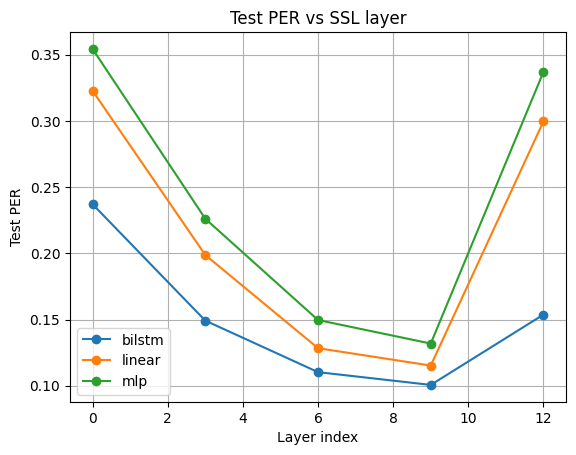

In [118]:
for head_name in results_df["head"].unique():
    subset = results_df[results_df["head"] == head_name].sort_values("layer_index")
    plt.plot(subset["layer_index"], subset["test_per"], marker="o", label=head_name)

plt.xlabel("Layer index")
plt.ylabel("Test PER")
plt.title("Test PER vs SSL layer")
plt.legend()
plt.grid(True)
plt.show()

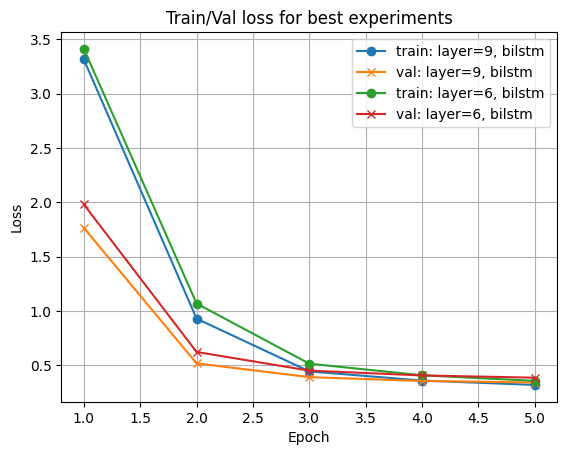

In [119]:
best_rows = results_df.head(2)[["layer_index", "head"]].values.tolist()

for layer_index, head_name in best_rows:
    subset = history_df[
        (history_df["layer_index"] == layer_index) &
        (history_df["head"] == head_name)
    ]

    plt.plot(subset["epoch"], subset["train_loss"], marker="o", label=f"train: layer={layer_index}, {head_name}")
    plt.plot(subset["epoch"], subset["val_loss"], marker="x", label=f"val: layer={layer_index}, {head_name}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Val loss for best experiments")
plt.legend()
plt.grid(True)
plt.show()

We will use several filters: 
- pre-emphasis, which amplifies high-frequency components of the signal, which are important for distinguishing phonemes, especially consonants.
- bandpass, which is in the range of 300–3400 Hz and is usually applied to retain the frequency range most relevant to human speech.
- wiener, which is an adaptive filtering method used for noise reduction.

In [131]:
from scipy.signal import wiener, butter, filtfilt

def pre_emphasis(x, alpha=0.97):
    y = np.copy(x)
    y[1:] = x[1:] - alpha * x[:-1]
    return y


def bandpass_filter(x, sr=16000, low=300, high=3400, order=4):

    nyq = 0.5 * sr
    low = low / nyq
    high = high / nyq

    b, a = butter(order, [low, high], btype='band')

    return filtfilt(b, a, x)


def wiener_filter(x):

    y = wiener(x)

    y = np.asarray(y, dtype=np.float32)

    y = np.nan_to_num(
        y,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return y

In [132]:
def apply_audio_filter(audio, filter_name, sr=16000):
    x = audio.detach().cpu().numpy().astype(np.float32)

    if filter_name == "none":
        y = x

    elif filter_name == "preemphasis":
        y = pre_emphasis(x, alpha=0.97)

    elif filter_name == "bandpass":
        y = bandpass_filter(x, sr=sr, low=300, high=3400, order=4)

    elif filter_name == "wiener":
        y = wiener_filter(x)

    else:
        raise ValueError(f"Unknown filter_name: {filter_name}")

    y = np.asarray(y, dtype=np.float32)
    return torch.tensor(y, dtype=torch.float32)

In [133]:
def rebuild_dataset_with_filter(df, filter_name, layer_index, split_name, cache_dir="cache"):
    cache_path = os.path.join(
        cache_dir,
        f"{split_name}_{filter_name}_layer{layer_index}.pt"
    )

    if os.path.exists(cache_path):
        print(f"Loading cached dataset: {cache_path}")
        return torch.load(cache_path)

    items = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name}-{filter_name}"):
        waveform, sr = torchaudio.load(row["wav_path"])

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0)
        else:
            waveform = waveform.squeeze(0)

        if sr != 16000:
            waveform = torchaudio.functional.resample(waveform, sr, 16000)
            sr = 16000

        waveform = waveform.squeeze()
        waveform = apply_audio_filter(waveform, filter_name, sr=sr)

        features = extract_ssl_features(
            audio=waveform,
            processor=processor,
            ssl_model=ssl_model,
            device=DEVICE,
            layer_index=layer_index,
        )

        label_ids = encode_phonemes(row["phonemes_39"], phoneme2id)

        items.append({
            "utt_id": row["utt_id"],
            "features": features.cpu(),
            "labels": torch.tensor(label_ids, dtype=torch.long),
            "phonemes_39": row["phonemes_39"],
            "text": row["text"],
        })

    torch.save(items, cache_path)
    print(f"Saved dataset to: {cache_path}")

    return items

In [134]:
best_row = results_df.sort_values("test_per").iloc[0]

best_layer = int(best_row["layer_index"])
best_head = best_row["head"]

print("Best baseline configuration:")
print("Layer:", best_layer)
print("Head:", best_head)
print("Baseline test PER:", best_row["test_per"])

Best baseline configuration:
Layer: 9
Head: bilstm
Baseline test PER: 0.10061575857090979


In [135]:
filters = ["preemphasis", "bandpass", "wiener"]

for filter_name in filters:
    print(f"\n=== Building cache for: {filter_name} ===")

    _ = rebuild_dataset_with_filter(train_df, filter_name, best_layer, "train", cache_dir="cache")
    _ = rebuild_dataset_with_filter(val_df, filter_name, best_layer, "val", cache_dir="cache")
    _ = rebuild_dataset_with_filter(test_df, filter_name, best_layer, "test", cache_dir="cache")


=== Building cache for: preemphasis ===
Loading cached dataset: cache/train_preemphasis_layer9.pt
Loading cached dataset: cache/val_preemphasis_layer9.pt
Loading cached dataset: cache/test_preemphasis_layer9.pt

=== Building cache for: bandpass ===
Loading cached dataset: cache/train_bandpass_layer9.pt
Loading cached dataset: cache/val_bandpass_layer9.pt
Loading cached dataset: cache/test_bandpass_layer9.pt

=== Building cache for: wiener ===


train-wiener:   0%|          | 0/4158 [00:00<?, ?it/s]/Users/akravchuk/vscodeprojects/sound_processing/.venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/Users/akravchuk/vscodeprojects/sound_processing/.venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
train-wiener: 100%|██████████| 4158/4158 [14:27<00:00,  4.79it/s]


Saved dataset to: cache/train_wiener_layer9.pt


val-wiener:   0%|          | 0/462 [00:00<?, ?it/s]/Users/akravchuk/vscodeprojects/sound_processing/.venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/Users/akravchuk/vscodeprojects/sound_processing/.venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
val-wiener: 100%|██████████| 462/462 [01:29<00:00,  5.14it/s]


Saved dataset to: cache/val_wiener_layer9.pt


test-wiener:   0%|          | 0/1680 [00:00<?, ?it/s]/Users/akravchuk/vscodeprojects/sound_processing/.venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/Users/akravchuk/vscodeprojects/sound_processing/.venv/lib/python3.11/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
test-wiener: 100%|██████████| 1680/1680 [05:43<00:00,  4.89it/s]


Saved dataset to: cache/test_wiener_layer9.pt


In [136]:
filters = ["preemphasis", "bandpass", "wiener"]

ablation_results = []
ablation_histories = []

for filter_name in filters:
    print(f"\nExperiment for filter: {filter_name} ")

    train_items = rebuild_dataset_with_filter(train_df, filter_name, best_layer, "train", cache_dir="cache")
    val_items = rebuild_dataset_with_filter(val_df, filter_name, best_layer, "val", cache_dir="cache")
    test_items = rebuild_dataset_with_filter(test_df, filter_name, best_layer, "test", cache_dir="cache")

    result, history_df, model = run_experiment(
        layer_index=best_layer,
        head_name=best_head,
        train_items=train_items,
        val_items=val_items,
        test_items=test_items,
        num_classes=num_classes,
        blank_id=blank_id,
        id2phoneme=id2phoneme,
        train_device=DEVICE,
        batch_size=8,
        lr=1e-3 if best_head == "linear" else 1e-4,
        num_epochs=5,
    )

    result["filter"] = filter_name
    ablation_results.append(result)

    history_df = history_df.copy()
    history_df["filter"] = filter_name
    ablation_histories.append(history_df)


Experiment for filter: preemphasis 
Loading cached dataset: cache/train_preemphasis_layer9.pt
Loading cached dataset: cache/val_preemphasis_layer9.pt
Loading cached dataset: cache/test_preemphasis_layer9.pt

Experiment for filter: bandpass 
Loading cached dataset: cache/train_bandpass_layer9.pt
Loading cached dataset: cache/val_bandpass_layer9.pt
Loading cached dataset: cache/test_bandpass_layer9.pt

Experiment for filter: wiener 
Loading cached dataset: cache/train_wiener_layer9.pt
Loading cached dataset: cache/val_wiener_layer9.pt
Loading cached dataset: cache/test_wiener_layer9.pt


In [137]:
ablation_df = pd.DataFrame(ablation_results).sort_values("test_per").reset_index(drop=True)
ablation_df

,layer_index,head,best_val_per,test_loss,test_per,num_epochs,batch_size,lr,filter
0,9,bilstm,0.098976,0.347194,0.100789,5,8,0.0001,wiener
1,9,bilstm,0.098844,0.348302,0.101127,5,8,0.0001,preemphasis
2,9,bilstm,0.103300,0.360808,0.101923,5,8,0.0001,bandpass


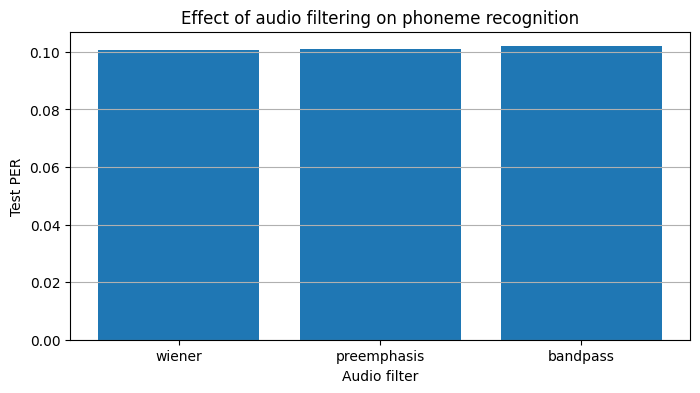

In [138]:
plt.figure(figsize=(8, 4))
plt.bar(ablation_df["filter"], ablation_df["test_per"])
plt.xlabel("Audio filter")
plt.ylabel("Test PER")
plt.title("Effect of audio filtering on phoneme recognition")
plt.grid(axis="y")
plt.show()

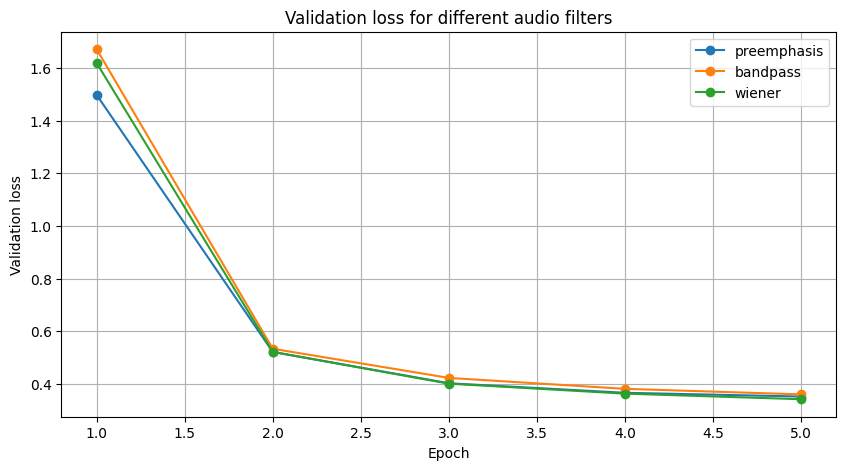

In [139]:
ablation_history_df = pd.concat(ablation_histories, ignore_index=True)

plt.figure(figsize=(10, 5))

for filter_name in ablation_history_df["filter"].unique():
    subset = ablation_history_df[ablation_history_df["filter"] == filter_name]
    plt.plot(
        subset["epoch"],
        subset["val_loss"],
        marker="o",
        label=f"{filter_name}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss for different audio filters")
plt.legend()
plt.grid(True)
plt.show()

In [140]:
ablation_df.to_csv("filter_ablation_results.csv", index=False)
ablation_history_df.to_csv("filter_ablation_history.csv", index=False)

print("Saved:")
print("filter_ablation_results.csv")
print("filter_ablation_history.csv")

Saved:
filter_ablation_results.csv
filter_ablation_history.csv
